In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Data Loading

customers = pd.read_csv("data/olist_customers_dataset.csv")

orders = pd.read_csv("data/olist_orders_dataset.csv")

order_items = pd.read_csv("data/olist_order_items_dataset.csv")

payments = pd.read_csv("data/olist_order_payments_dataset.csv")

products = pd.read_csv("data/olist_products_dataset.csv")

reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

translation = pd.read_csv(
    "data/product_category_name_translation.csv"
)

In [3]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Translation:", translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)
Reviews: (99224, 7)
Translation: (71, 2)


In [4]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [5]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [6]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [7]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [8]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [9]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [10]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
#Merge 1
master = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(master.shape)

(112650, 15)


In [14]:
#Merge 2
master = master.merge(
    orders,
    on="order_id",
    how="left"
)

master.shape

(112650, 22)

In [15]:
#Merge 3
master = master.merge(
    customers,
    on="customer_id",
    how="left"
)

master.shape

(112650, 26)

In [16]:
#Merge 4
master = master.merge(
    payments,
    on="order_id",
    how="left"
)

master.shape

(117604, 30)

In [17]:
#Merge 5
master = master.merge(
    reviews,
    on="order_id",
    how="left"
)

master.shape

(118310, 36)

In [18]:
master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59


In [19]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118310 non-null  str    
 1   order_item_id                  118310 non-null  int64  
 2   product_id                     118310 non-null  str    
 3   seller_id                      118310 non-null  str    
 4   shipping_limit_date            118310 non-null  str    
 5   price                          118310 non-null  float64
 6   freight_value                  118310 non-null  float64
 7   product_category_name          116601 non-null  str    
 8   product_name_lenght            116601 non-null  float64
 9   product_description_lenght     116601 non-null  float64
 10  product_photos_qty             116601 non-null  float64
 11  product_weight_g               118290 non-null  float64
 12  product_length_cm              118290 non

In [20]:
master.shape

(118310, 36)

#Data Cleaning

In [21]:
date_cols = [
    'shipping_limit_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    master[col] = pd.to_datetime(master[col])

In [22]:
master[date_cols].dtypes

shipping_limit_date              datetime64[us]
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
review_creation_date             datetime64[us]
review_answer_timestamp          datetime64[us]
dtype: object

In [23]:
master.isnull().sum().sort_values(ascending=False)

review_comment_title             104418
review_comment_message            68628
order_delivered_customer_date      2588
product_category_name              1709
product_description_lenght         1709
product_photos_qty                 1709
product_name_lenght                1709
order_delivered_carrier_date       1254
review_score                        978
review_answer_timestamp             978
review_creation_date                978
review_id                           978
product_height_cm                    20
product_weight_g                     20
product_length_cm                    20
product_width_cm                     20
order_approved_at                    15
payment_sequential                    3
payment_installments                  3
payment_type                          3
payment_value                         3
product_id                            0
order_item_id                         0
order_id                              0
seller_id                             0


In [24]:
master["order_status"].value_counts()

order_status
delivered      115723
shipped          1255
canceled          570
invoiced          376
processing        376
unavailable         7
approved            3
Name: count, dtype: int64

In [25]:
master = master[
    master["order_status"] == "delivered"
]

In [26]:
snapshot_date = master["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2018-08-30 15:00:37


In [27]:
rfm = master.groupby("customer_unique_id").agg({
    "order_purchase_timestamp":
        lambda x: (snapshot_date - x.max()).days,

    "order_id": "nunique",

    "payment_value": "sum"
})

In [28]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [29]:
rfm.shape

(93358, 3)

In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,212.964557
std,152.591453,0.209097,646.223866
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.830000
50%,219.000000,1.000000,113.140000
75%,346.000000,1.000000,202.637500
max,714.000000,15.000000,109312.640000


In [31]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [32]:
rfm.to_csv(
    "data/rfm_dataset.csv",
    index=True
)

In [33]:
rfm.shape

(93358, 3)

In [34]:
rfm.shape

(93358, 3)

Checking for the Outliers

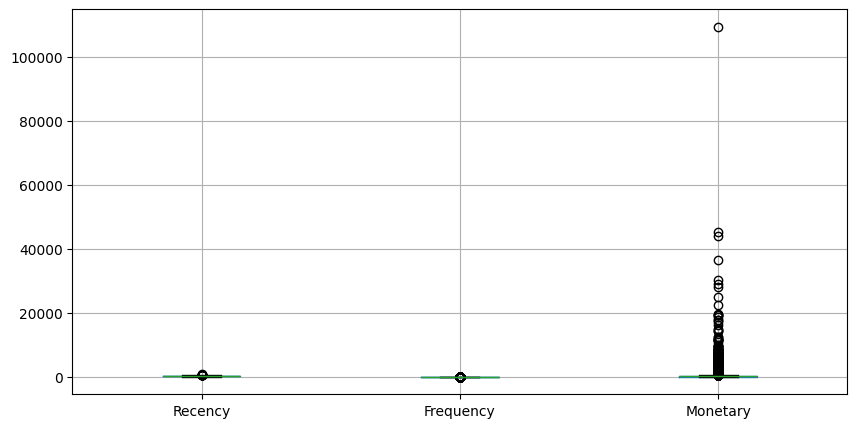

In [35]:
rfm.boxplot(figsize=(10,5))
plt.show()

In [36]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled.shape

(93358, 3)

In [37]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

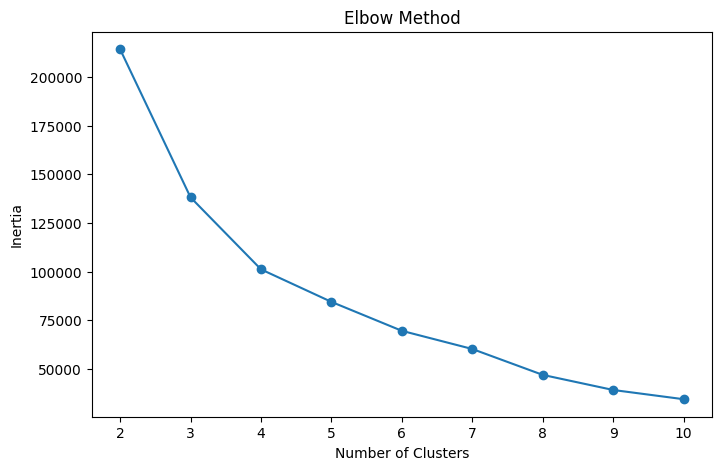

In [38]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [40]:
rfm["Cluster"].value_counts()

Cluster
1    52145
3    38394
2     2797
0       22
Name: count, dtype: int64

In [41]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,214.227273,1.272727,26932.410000
1,128.474600,1.000000,198.610358
2,220.344297,2.113336,454.363654
3,387.910715,1.000000,199.563468


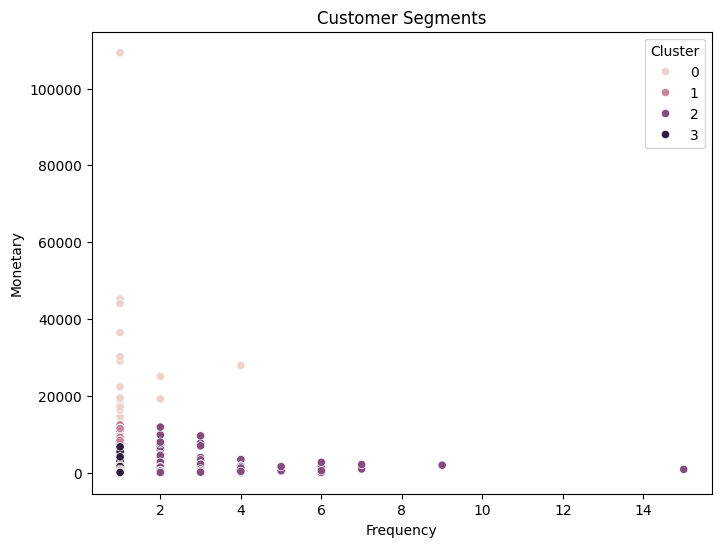

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster"
)

plt.title("Customer Segments")
plt.show()

In [43]:
Q1 = rfm["Monetary"].quantile(0.25)
Q3 = rfm["Monetary"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

rfm_clean = rfm[
    rfm["Monetary"] <= upper_limit
]

In [44]:
rfm_clean.shape

(84220, 4)

In [45]:
scaler = StandardScaler()

rfm_clean_scaled = scaler.fit_transform(
    rfm_clean[["Recency", "Frequency", "Monetary"]]
)

In [46]:
rfm_clean_scaled.shape

(84220, 3)

In [47]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm_clean["Cluster"] = kmeans.fit_predict(
    rfm_clean_scaled
)

In [48]:
rfm_clean["Cluster"].value_counts()

Cluster
2    38513
1    28177
0    15552
3     1978
Name: count, dtype: int64

In [49]:
cluster_summary = rfm_clean.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,224.79,1.00,263.48
1,396.83,1.00,92.15
2,128.34,1.00,88.72
3,222.69,2.06,211.18


In [50]:
cluster_names = {
    0: "High Value Customers",
    1: "At Risk Customers",
    2: "Active Customers",
    3: "Loyal Customers"
}

rfm_clean["Segment"] = rfm_clean["Cluster"].map(cluster_names)

In [51]:
rfm_clean["Segment"].value_counts()

Segment
Active Customers        38513
At Risk Customers       28177
High Value Customers    15552
Loyal Customers          1978
Name: count, dtype: int64

In [52]:
rfm_clean.to_csv(
    "data/customer_segments.csv",
    index=True
)

In [53]:
master.to_csv(
    "data/master_dataset.csv",
    index=False
)

In [54]:
segment_summary = rfm_clean.groupby("Segment").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

segment_summary.to_csv(
    "data/segment_summary.csv"
)

In [59]:
import pickle
from sklearn.metrics.pairwise import cosine_similarity

if "product_category_name_english" not in master.columns:
    master = master.merge(translation, on="product_category_name", how="left")

master_rec = master.dropna(subset=["customer_unique_id", "product_category_name_english"]).copy()

pivot = (
    master_rec
    .groupby(["customer_unique_id", "product_category_name_english"])["order_id"]
    .count()
    .unstack()
    .fillna(0)
)

print("Pivot shape:", pivot.shape)  # (n_customers, n_product_categories)

sim_matrix = cosine_similarity(pivot.T)   # shape: (n_categories, n_categories)
product_index = {name: idx for idx, name in enumerate(pivot.columns)}

print("Products indexed:", len(product_index))
print("Sample categories:", list(product_index.keys())[:5])

with open("data/similarity_matrix.pkl", "wb") as f:
    pickle.dump(sim_matrix, f)

with open("data/product_index.pkl", "wb") as f:
    pickle.dump(product_index, f)

print("Saved similarity_matrix.pkl and product_index.pkl")

Pivot shape: (92079, 71)
Products indexed: 71
Sample categories: ['agro_industry_and_commerce', 'air_conditioning', 'art', 'arts_and_craftmanship', 'audio']
Saved similarity_matrix.pkl and product_index.pkl


In [57]:
label_map = {0: "High-Value", 1: "At-Risk", 2: "Regular", 3: "Occasional"}
bundle = {"scaler": scaler, "kmeans": kmeans, "label_map": label_map}
with open('data/kmeans_model.pkl', 'wb') as f: pickle.dump(bundle, f)

In [60]:
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Re-fit scaler and kmeans on rfm_clean (already computed in your notebook)
scaler = StandardScaler()
rfm_clean_scaled = scaler.fit_transform(rfm_clean[["Recency", "Frequency", "Monetary"]])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm_clean["Cluster"] = kmeans.fit_predict(rfm_clean_scaled)

# Check your cluster_summary to map these correctly
print(rfm_clean.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(2))

         Recency  Frequency  Monetary
Cluster                              
0         224.79       1.00    263.48
1         396.83       1.00     92.15
2         128.34       1.00     88.72
3         222.69       2.06    211.18


In [62]:
# Adjust label_map numbers to match YOUR cluster_summary output above
label_map = {
    0: "High Value Customers",
    1: "At Risk Customers",
    2: "Active Customers",
    3: "Loyal Customers"
}

bundle = {"scaler": scaler, "kmeans": kmeans, "label_map": label_map}

with open("data/kmeans_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Saved!")

Saved!
